# Filing-aware options: does the 8-K add value?

**Gator Quant Hacks 2026 · Massive challenge.** This notebook follows the provided starter workflow and imports reusable event, signal, pricing, and portfolio modules from `skew8k/`. It makes each research step visible: event and placebo construction, pre-filing IV signal, option-leg marks, five standard strategies, advanced comparisons, and risk checks.

**Question.** Does an unusual pre-filing call-versus-put IV signal perform better when paired with an Item 7.01 filing than on comparable ordinary days? The filing is auxiliary context, not a directional signal. We test that claim against matched placebo sessions and report uncertainty and costs. The saved results are positive in places but statistically weak; they do not establish consistent profitability.

## 1 · Setup and configuration
Everything a reader may change is in the next cell. Only `MASSIVE_API_KEY` is required (environment or `.env`).

100 names; development 2022-03-07 .. 2024-12-31


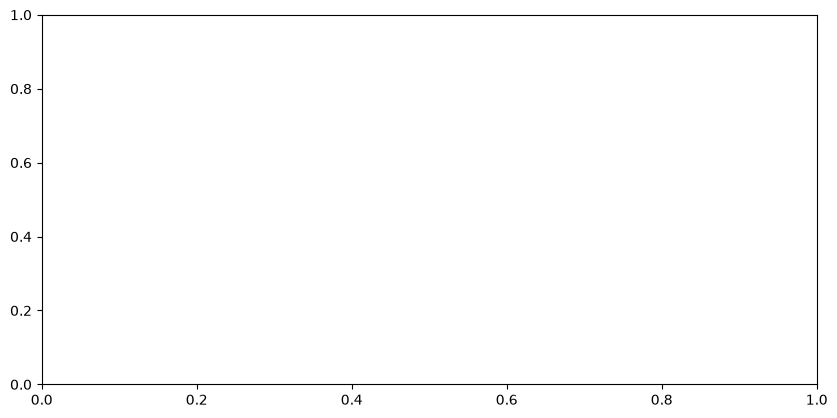

In [1]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from skew8k import engine as E, study as S
from skew8k.signal import load_iv, skew_z, attach
from skew8k.pipeline import run_study
from skew8k.pipeline import run_study

ITEM = "7.01"                                          # SEC item: Regulation FD (voluntary) disclosure
STUDY_START, STUDY_END = "2022-03-07", "2024-12-31"     # in-sample filing/signal dates
EVAL_START, EVAL_END = "2025-01-02", "2026-10-02"       # reserved window through the last completed session
EVAL_WARMUP_START = (pd.Timestamp(EVAL_START) - pd.Timedelta(days=100)).strftime("%Y-%m-%d")
RUN_EVALUATION = False                                 # keep the reserved evaluation sealed
BUCKET, OTM, HAIRCUT, HOLD = "3-6m", 0.05, 0.02, "10"   # headline contracts, cost per option leg per side, holding period (sessions)
N_PLACEBO = 600
MAX_IO_WORKERS = 6
MAX_IO_WORKERS = 6
IV_PATH = "data/iv180_top100.parquet"                  # daily 180-day American IV from Massive quotes; rebuilt from the API if absent
UNIVERSE = E.TOP_100
os.makedirs("results", exist_ok=True); os.makedirs("note/figs", exist_ok=True)
print(len(UNIVERSE), "names; development", STUDY_START, "..", STUDY_END)

## 2 · Event definition and timing

Item 7.01 is the Regulation FD disclosure section of Form 8-K. Companies may use it to make information broadly public after it has been shared selectively; the item covers varied topics, so it does not tell us whether a stock should rise or fall. We use the filing only to define the event group. [Investor.gov explains Item 7.01 and Form 8-K](https://www.investor.gov/introduction-investing/general-resources/news-alerts/alerts-bulletins/investor-bulletins/how-read-8).

The filing date is mapped to the first trading session strictly after that date. This conservative rule avoids assuming we knew the filing time or could trade on the same day. Controls are randomly selected sessions for the same companies, kept at least 10 sessions from their filings.


In [2]:
ev = S.item_events(ITEM, STUDY_START, STUDY_END, UNIVERSE)
ev = ev.drop_duplicates(["ticker", "event_date"])
pl = S.placebo(ev, N_PLACEBO, STUDY_START, STUDY_END)
print(len(ev), "Item", ITEM, "filings across", ev.ticker.nunique(), "names;", len(pl), "placebo sessions")
ev.groupby(pd.to_datetime(ev.event_date).dt.year).size().rename("filings").to_frame().T

694 'item_7.01' disclosures across all filers, 2022-03-07..2024-12-31


691

 Item 7.01 filings across 83 names; 600 placebo sessions


event_date,2022,2023,2024
filings,221,233,237


## 3 · The signal: pre-filing option-implied skew

Implied volatility (IV) is the volatility input that makes an option-pricing model match an observed option price. It is a market-priced uncertainty measure, not a direct count of trader positions or a promise of future realized volatility.

For company $i$ on session $t$, call-minus-put skew is $k_{i,t} = \sigma^{C}_{i,t} - \sigma^{P}_{i,t}$. We subtract the company’s trailing 60-session average, using only earlier sessions (at least 30 valid prior observations), then standardize that residual across companies on the same date. The resulting $z_{i,t}$ is a relative signal: positive means call IV is unusually high relative to that company’s recent history and its peers.

High-skew observations use the fixed cutoff $z > 0.43$; low-skew observations use $z < -0.43$. These are nominal normal-distribution third cutoffs, not guaranteed empirical terciles. The signal is read on `t_pre`, before the filing date.


### How the 180-day IV panel is constructed

For each company and session, the builder takes spot from the last completed 5-minute bar at 15:55 ET. It selects the standard listed expiry closest to 180 calendar days (within 150–210 days), then the strike nearest spot that has both a call and a put. For each option it takes a valid bid/ask midpoint from a quote no more than 60 seconds old, gathered in the preceding five minutes. A QuantLib American-option model converts that midpoint into annualized IV, using the prior Treasury yield and trailing paid cash dividends as carry. Rows missing either side’s valid IV are excluded.

The feature is call IV minus put IV at the matched strike and expiry, less the company’s trailing 60-session average, then cross-sectionally standardized. This suppresses slow company-specific carry and highlights relative repricing. It remains a proxy; it does not observe open positions. IV quotes build the predictor. Later option daily bars provide the modeled entry and exit marks, so the signal and payoff inputs are distinct.

In [3]:
iv = load_iv("2021-12-01", STUDY_END, UNIVERSE, IV_PATH)
Z = skew_z(iv)
ev, pl = attach(ev, Z), attach(pl, Z)
pd.concat([ev.tercile.value_counts().rename("events"), pl.tercile.value_counts().rename("placebo")], axis=1)

,events,placebo
tercile,,
mid,209,211
none,201,168
bottom,144,98
top,137,123


## 4 · Price the trades with the starter engine
For each event: the chain as of `t_pre`, spot from put-call parity, the 3–6 month expiry, the ATM strike and 3/5/10% OTM strikes, and every leg's daily bars. We store each leg's mark at `t_0` and at every fixed horizon, so any structure is a linear combination.

In [4]:
legs = S.price(pd.concat([ev, pl], ignore_index=True), threads=MAX_IO_WORKERS, data_end=STUDY_END)
P = S.pnl(legs, OTM, HAIRCUT, BUCKET).merge(pd.concat([ev, pl])[["ticker", "event_date", "kind", "tercile", "skew_z", "t_0"]], on=["ticker", "event_date", "kind"])
P = P[P.tercile != "none"]
print(legs[legs.horizon == "0"].groupby("kind").size().to_dict(), "priced events")

{'event': 649, 'placebo': 543} priced events


## 5 · The five starter strategies, and what the 8-K adds
Three rows per strategy at 10 and 21 sessions: ordinary days (placebo), every Item 7.01 filing, and Item 7.01 filings whose pre-filing skew was in the high-skew bucket. The last column is the finding: **filing × skew minus placebo × same skew**, with its t-statistic.

### Reproduced-result reading guide

With the pinned research dependencies and outcomes capped at December 31, 2024, the high-skew protective-put event-minus-placebo gap is +0.39% of entry spot at 10 sessions (t = 0.67) and +0.56% at 21 sessions (t = 0.61). The 33-cohort annualized Sharpe is 0.42, below the requested threshold. The following cells regenerate the comparison tables; see `results/library_vs_placebo.csv` and `results/portfolio_stats.csv`.

![Net modeled P&L for high-skew Item 7.01 events versus matched high-skew placebo sessions, as a percentage of entry spot. The labeled t-statistics show that the positive gaps are uncertain.](note/figs/event_vs_placebo.png)


In [5]:
ev_all, ev_top = P[P.kind == "event"], P[(P.kind == "event") & (P.tercile == "top")]
pl_all, pl_top = P[P.kind == "placebo"], P[(P.kind == "placebo") & (P.tercile == "top")]
rows = []
for s in ["stock"] + S.LIBRARY:
    for h in ("10", "21"):
        m = lambda d: 100 * d[d.horizon == h][f"{s}_bull"].mean()
        g, t = S.gap(ev_top, pl_top, s, h)
        rows.append({"strategy": s, "h": h, "placebo": m(pl_all), "all 7.01": m(ev_all), "7.01 x top skew": m(ev_top), "placebo x top skew": m(pl_top), "gap": g, "t": t})
lib = pd.DataFrame(rows).round(2); lib
lib.to_csv("results/library_vs_placebo.csv", index=False)
display(lib)


,strategy,h,placebo,all 7.01,7.01 x top skew,placebo x top skew,gap,t
0,stock,10,0.54,0.49,1.24,0.54,0.70,0.94
1,stock,21,1.47,1.54,1.85,0.75,1.10,0.90
2,long_call,10,-0.09,-0.09,0.19,-0.10,0.29,0.62
3,long_call,21,0.47,0.49,0.62,0.08,0.54,0.71
4,covered_call,10,0.17,0.10,0.59,0.23,0.36,0.77
5,covered_call,21,0.55,0.61,0.74,0.15,0.59,0.78
6,protective_put,10,0.28,0.21,0.73,0.34,0.39,0.67
7,protective_put,21,1.04,0.98,1.25,0.69,0.56,0.61
8,collar,10,-0.12,-0.22,0.04,-0.04,0.07,0.27
9,collar,21,0.13,0.10,0.18,0.12,0.05,0.14


In [6]:
hz_rows = []
for h in ["1", "2", "3", "5", "10", "21", "42", "63", "exp"]:
    a, b = ev_top[ev_top.horizon == h].protective_put_bull.dropna(), pl_top[pl_top.horizon == h].protective_put_bull.dropna()
    lo, hi = S.ci(a); g, t = S.gap(ev_top, pl_top, "protective_put", h)
    hz_rows.append({"horizon": h, "event_%": 100 * a.mean(), "ci_lo_%": 100 * lo, "ci_hi_%": 100 * hi, "hit": (a > 0).mean(), "placebo_%": 100 * b.mean(), "gap_%": g, "t": t, "n": len(a)})
hz_tab = pd.DataFrame(hz_rows).round(2); hz_tab.to_csv("results/horizons.csv", index=False); hz_tab

,horizon,event_%,ci_lo_%,ci_hi_%,hit,placebo_%,gap_%,t,n
0,1,-0.16,-0.41,0.08,0.43,-0.18,0.01,0.08,131
1,2,-0.39,-0.76,-0.03,0.37,-0.13,-0.26,-1.10,131
2,3,-0.41,-0.81,-0.03,0.41,-0.01,-0.39,-1.34,128
3,5,-0.13,-0.60,0.34,0.42,-0.01,-0.13,-0.32,126
4,10,0.73,-0.04,1.56,0.49,0.34,0.39,0.67,121
5,21,1.25,-0.06,2.72,0.50,0.69,0.56,0.61,121
6,42,0.88,-0.90,2.95,0.46,0.92,-0.04,-0.03,110
7,63,1.96,-0.26,4.34,0.50,1.39,0.56,0.37,98
8,exp,1.95,-0.38,4.40,0.49,0.10,1.84,1.03,100


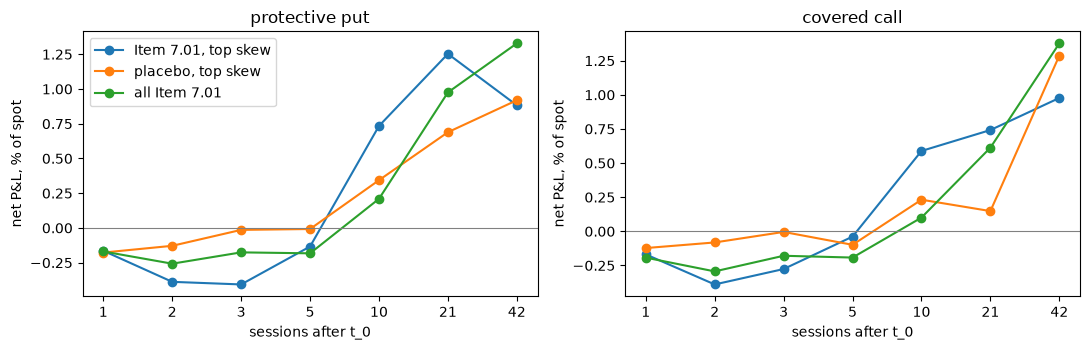

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), facecolor="white")
H = ["1", "2", "3", "5", "10", "21", "42"]
for a, s in zip(ax, ["protective_put", "covered_call"]):
    for d, lab in [(ev_top, "Item 7.01, top skew"), (pl_top, "placebo, top skew"), (ev_all, "all Item 7.01")]:
        a.plot(H, [100 * d[d.horizon == h][f"{s}_bull"].mean() for h in H], marker="o", label=lab)
    a.axhline(0, color="grey", lw=0.8); a.set_title(s.replace("_", " ")); a.set_xlabel("sessions after t_0"); a.set_ylabel("net P&L, % of spot")
ax[0].legend(); plt.tight_layout(); plt.savefig("note/figs/horizon_profile.png", dpi=150); plt.show()

### 5b · Year by year
The headline structure (protective put, 10 sessions) and the stock alone, high-skew filings versus high-skew placebo, each development year.

In [8]:
yy = []
for y in range(2022, 2025):
    a, b = ev_top[pd.to_datetime(ev_top.event_date).dt.year == y], pl_top[pd.to_datetime(pl_top.event_date).dt.year == y]
    for s in ("protective_put", "stock"):
        g, t = S.gap(a, b, s, "10")
        yy.append({"year": y, "strategy": s, "event_%": 100 * a[a.horizon == "10"][f"{s}_bull"].mean(), "placebo_%": 100 * b[b.horizon == "10"][f"{s}_bull"].mean(), "gap_%": g, "n": int(a[a.horizon == "10"][f"{s}_bull"].notna().sum())})
yy = pd.DataFrame(yy).round(2); yy.to_csv("results/by_year.csv", index=False); yy.pivot(index="year", columns="strategy", values=["event_%", "placebo_%", "gap_%"])

event_%            placebo_%                gap_%      
strategy protective_put stock protective_put stock protective_put stock
year                                                                   
2022               0.84  1.63          -0.75 -1.09           1.58  2.72
2023               0.93  1.38           0.48  0.97           0.45  0.41
2024               0.46  0.76           0.91  1.11          -0.46 -0.35

### 5c · Monthly cohort summary

For each month, average the net modeled P&L of qualifying protective-put trades entered in that month and held for 10 sessions. This summarizes the opportunity set; it is not a self-financing account return or a complete model of cash allocation and overlapping positions. The placebo cohort series uses ordinary sessions with the same skew filter. Annualized Sharpe is calculated from these monthly cohort means.

,months,sharpe_ann,total_%,worst_month_%,max_dd_%,pos_months
Item 7.01 x top skew: protective put,33.0,0.42,10.85,-3.92,6.54,0.42
placebo x top skew: protective put,33.0,-0.08,-2.59,-9.16,19.10,0.58
all Item 7.01: protective put,33.0,0.25,5.16,-3.62,10.28,0.48


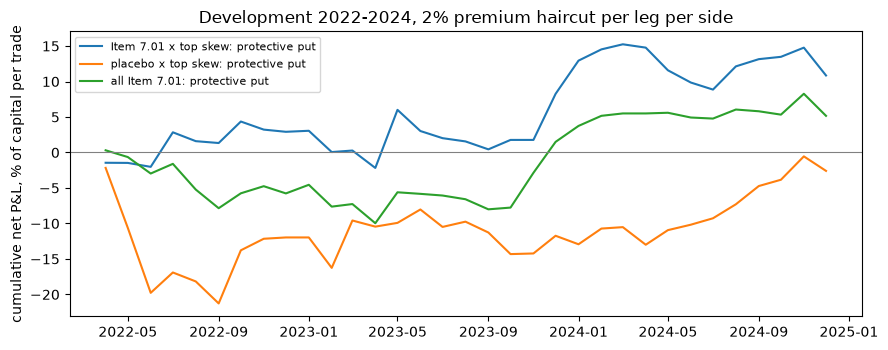

In [9]:
books = {"Item 7.01 x top skew: protective put": S.cohorts(ev_top, "protective_put", "10"),
         "placebo x top skew: protective put": S.cohorts(pl_top, "protective_put", "10"),
         "all Item 7.01: protective put": S.cohorts(ev_all, "protective_put", "10")}
st = pd.DataFrame({k: S.stats(v) for k, v in books.items()}).T.round(2); st.to_csv("results/portfolio_stats.csv"); display(st)
fig, ax = plt.subplots(figsize=(9, 3.6), facecolor="white")
for k, v in books.items():
    ax.plot(v.index.to_timestamp(), 100 * v.cumsum(), label=k)
ax.axhline(0, color="grey", lw=0.8); ax.set_ylabel("cumulative net P&L, % of capital per trade"); ax.legend(fontsize=8); ax.set_title("Development 2022-2024, 2% premium haircut per leg per side")
plt.tight_layout(); plt.savefig("note/figs/cumulative_is.png", dpi=150); plt.show()

## 6 · Bonus: advanced structures
The signal is two-sided, so each structure can take a bearish mirror when puts are relatively expensive (low-skew bucket): protective call instead of protective put, bear put spread instead of bull call spread, and so on. Directed trades use both thirds; short-volatility structures are shown as controls.

In [10]:
both = P[(P.kind == "event") & P.tercile.isin(["top", "bottom"])]
adv = S.board(both, ["stock"] + S.LIBRARY + S.ADVANCED, horizons=("5", "10", "21"), side="directed").round(3)
adv.pivot(index="strategy", columns="horizon", values="mean_%").round(2)

horizon,10,21,5
strategy,,,
bull_call_spread,-0.34,-0.30,-0.34
cash_secured_put,0.01,-0.09,-0.03
collar,-0.13,-0.07,-0.23
covered_call,0.25,0.29,-0.00
long_call,0.10,0.29,-0.18
protective_put,0.39,0.55,-0.06
risk_reversal,0.25,0.30,-0.14
short_straddle,-0.69,-0.84,-0.47
short_strangle,-0.49,-0.74,-0.24


In [11]:
top_adv = S.board(ev_top, S.LIBRARY + S.ADVANCED, horizons=("10", "21")).round(2)
top_adv.pivot(index="strategy", columns="horizon", values="mean_%").sort_values("10", ascending=False)

horizon,10,21
strategy,,
protective_put,0.73,1.25
risk_reversal,0.60,0.93
covered_call,0.59,0.74
cash_secured_put,0.23,0.20
long_call,0.19,0.62
collar,0.04,0.18
bull_call_spread,-0.36,-0.38
short_strangle,-0.46,-0.89
short_straddle,-0.64,-0.99


## 7 · Costs and sensitivity

We assume 2% of option premium per leg per side and show neighboring 0%, 3%, and 5% haircuts. Stock legs pay 3 basis points per side. The existing sensitivity grid varies OTM distance, cost, and holding horizon, comparing high-skew Item 7.01 filings with high-skew placebo sessions. It does not claim that a fixed haircut reproduces every executable bid/ask fill.

In [12]:
sens = []
for otm in E.OTM_GRID:
    for hc in (0.0, 0.02, 0.03, 0.05):
        Q = S.pnl(legs, otm, hc, BUCKET).merge(pd.concat([ev, pl])[["ticker", "event_date", "kind", "tercile"]], on=["ticker", "event_date", "kind"])
        a = Q[(Q.kind == "event") & (Q.tercile == "top")]
        b = Q[(Q.kind == "placebo") & (Q.tercile == "top")]
        for h in ("10", "21"):
            g, t = S.gap(a, b, "protective_put", h)
            sens.append({"otm": otm, "haircut": hc, "h": h, "event_%": 100 * a[a.horizon == h].protective_put_bull.mean(), "gap_%": g, "t": t})
sens = pd.DataFrame(sens).round(2)
sens.to_csv("results/sensitivity.csv", index=False)
display(sens)


,otm,haircut,h,event_%,gap_%,t
0,0.03,0.00,10,0.76,0.32,0.58
1,0.03,0.00,21,1.39,0.63,0.72
2,0.03,0.02,10,0.58,0.30,0.54
3,0.03,0.02,21,1.21,0.61,0.69
4,0.03,0.03,10,0.49,0.29,0.51
5,0.03,0.03,21,1.12,0.59,0.67
6,0.03,0.05,10,0.32,0.27,0.47
7,0.03,0.05,21,0.93,0.57,0.64
8,0.05,0.00,10,0.88,0.41,0.70
9,0.05,0.00,21,1.40,0.58,0.63


## 8 · Development/evaluation boundary

The in-sample filing and signal window ends December 31, 2024. Reserved evaluation dates appear at the end of this notebook as configuration only; execution is disabled and no evaluation results are included here.

## What the comparisons show

The full in-sample reproduction shows a positive protective-put event-minus-placebo gap: 0.39 percentage points of entry spot at 10 sessions (t = 0.67) and 0.56 points at 21 sessions (t = 0.61). These differences are too uncertain to establish a reliable effect. Risk reversal is a useful bonus comparison: at 21 sessions its high-skew filing mean is 0.93%, above four standard structures but below the protective put at 1.25%. The filing group’s protective-put gap remains negative in 2024. No evaluation results are reported.

## Trade specification

- **Event timing:** first trading session strictly after an Item 7.01 filing; the event does not determine trade direction.
- **Signal:** high-skew bucket of the pre-filing, cross-sectionally ranked 180-day call-minus-put IV residual.
- **Headline structure:** 100 shares plus one 3–6 month put about 5% below spot; exit after 10 sessions.
- **Costs:** 2% of option premium per leg per side and 3 basis points per stock side.
- **Limits:** static large-cap universe, last-trade option marks, small yearly samples, and no demonstrated Sharpe above the competition target. Read the uncertainty intervals, not just the means.

## Reserved evaluation configuration

The evaluation configuration is January 2, 2025 through October 2, 2026, the latest completed market session as of this package date. It is disabled by default. When the organizers authorize the test, call `run_study(EVAL_START, EVAL_END, ...)`. The helper starts IV history 100 calendar days before the requested start (`EVAL_WARMUP_START`) so the trailing 60-session feature is initialized using past data. Warm-up rows build features only; event and placebo rows remain within the requested evaluation dates. The final holding horizons near the end date remain incomplete until exit marks occur. No evaluation run is performed in this notebook.

In [13]:
# Authorized evaluation only; deliberately disabled while the reserved window is sealed.
# evaluation = run_study(EVAL_START, EVAL_END, item=ITEM, universe=UNIVERSE,
#                        n_placebo=N_PLACEBO, iv_path=IV_PATH, threads=MAX_IO_WORKERS)


### Reusable pipeline

`skew8k.pipeline.run_study(start, end, ...)` runs the same steps shown above: filings, same-name placebo sessions, IV180 warm-up and signal attachment, option-leg pricing, and net P&L. The requested end date caps option-bar marks, so incomplete horizons are left unavailable rather than filled using later dates. The in-sample run uses the explicit 2022–2024 dates in the configuration cell.